# A Geo-Agent Without the AI
### Natural-language spatial proximity queries · Portland, Oregon · OpenStreetMap · no keys, no LLM

The theme of a typical "geoAI" agent has the same skeleton: take a plain-English question, figure out
what it's asking, resolve the place names, run a spatial query, compose an answer. The language
model only does the *first* of those steps. Everything else — geocoding, coordinate reference
systems, distance semantics, tag vocabularies, the query itself — is unglamorous spatial plumbing.
This notebook builds all of that plumbing and swaps the learned component for a regex and a lookup
table, so the whole thing runs with **zero API keys and zero accounts**:

> *"How many parks are there within a mile of Portland State University?"*
> *"How many coffee shops are there within a quarter mile of Powell's Books?"*

**The pipeline** — the same three stages an LLM-driven geo-agent has, with stage 1 de-glamorized:

| Stage | What it does | This notebook uses |
|---|---|---|
| 1 · **Parse** | Turn language into structured intent: *(what, how far, where)* | Regex + a vocabulary table |
| 2 · **Ground** | Resolve the place name to coordinates | Nominatim geocoder (keyless) |
| 3 · **Act** | Run the spatial query and compose the answer | OSMnx → Overpass, GeoPandas in EPSG:32610 |

Section 9 shows exactly where an LLM would slot in — stages 2 and 3 wouldn't change a line.
If you're evaluating geoAI tools, that's a useful mental model: the model buys you open-ended
language; the geospatial rigor still has to come from somewhere.

> ⚠️ **This notebook requires an internet connection at runtime** — it queries live OSM
> services (politely; see the etiquette note at the end).


## 1 — Setup

One dependency does all the heavy lifting. OSMnx bundles the Nominatim and Overpass clients
and returns GeoDataFrames.


In [1]:
# [Terminal] — run once in your environment, not in this cell
# pip install osmnx matplotlib

# [Python]
import re
import osmnx as ox
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point

# Identify yourself to the free OSM services (Nominatim usage policy)
ox.settings.http_user_agent = "GISPR-geoai-demo (educational)"
ox.settings.requests_timeout = 60

print(f"osmnx {ox.__version__}")   # written against osmnx 2.x


osmnx 2.1.0


## 2 — The vocabulary: English terms → OSM tags

This table **is** the agent's world model. Each plain-English term maps to the
[OSM tag query](https://wiki.openstreetmap.org/wiki/Map_features) that Overpass understands.
Extending the agent = adding a row.


In [2]:
# [Python]
TAG_MAP = {
    "park":           {"leisure": "park"},
    "coffee shop":    {"amenity": "cafe"},
    "cafe":           {"amenity": "cafe"},
    "restaurant":     {"amenity": "restaurant"},
    "bar":            {"amenity": ["bar", "pub"]},
    "brewery":        {"craft": "brewery"},
    "library":        {"amenity": "library"},
    "school":         {"amenity": "school"},
    "grocery store":  {"shop": "supermarket"},
    "supermarket":    {"shop": "supermarket"},
    "hospital":       {"amenity": "hospital"},
    "pharmacy":       {"amenity": "pharmacy"},
    "bus stop":       {"highway": "bus_stop"},
    "bike shop":      {"shop": "bicycle"},
    "food cart":      {"amenity": "fast_food"},
    "bookstore":      {"shop": "books"},
    "playground":     {"leisure": "playground"},
}

# Accept plurals without duplicating rows: "parks" → "park", "pharmacies" → "pharmacy"
def normalize_term(term):
    t = term.lower().strip()
    if t in TAG_MAP:
        return t
    if t.endswith("ies") and t[:-3] + "y" in TAG_MAP:      # pharmacies → pharmacy
        return t[:-3] + "y"
    if t.endswith("s") and t[:-1] in TAG_MAP:              # parks → park
        return t[:-1]
    return None


## 3 — Parse stage: distance phrases

Handles the ways people actually say distances: *"a mile"*, *"quarter mile"*, *"half a mile"*,
*"three quarters of a mile"*, *"800 meters"*, *"1.5 km"*, *"2 miles"*.


In [3]:
# [Python]
MI_TO_M = 1609.344
FRACTIONS = {
    "a quarter": 0.25, "quarter": 0.25,
    "a third": 1/3,    "third": 1/3,
    "half a": 0.5,     "a half": 0.5, "half": 0.5,
    "three quarters of a": 0.75, "three-quarters of a": 0.75,
}

def parse_distance(text):
    """Convert a distance phrase to meters."""
    t = re.sub(r"\bof a\b", "", text.lower().strip()).strip()

    m = re.match(r"([\d.]+)\s*(miles?|mi|kilometers?|km|meters?|m)\b", t)
    if m:                                          # "2 miles", "800 meters", "1.5 km"
        val, unit = float(m.group(1)), m.group(2)
        if unit.startswith("mi"): return val * MI_TO_M
        if unit.startswith("k"):  return val * 1000
        return val

    for phrase, frac in sorted(FRACTIONS.items(), key=lambda kv: -len(kv[0])):
        if t.startswith(phrase):                   # "quarter mile", "half a mile"
            return frac * MI_TO_M

    if re.match(r"(a|an|one)\s+mile", t):          # "a mile"
        return MI_TO_M
    if re.match(r"(a|an|one)\s+(kilometer|km)", t):
        return 1000.0
    raise ValueError(f"Couldn't parse the distance: '{text}'")


## 4 — Parse stage: the question

One regex covers the target question shape:
`How many <things> are there within <distance> of <place>?`

A rule-based parser is brittle by design — the failure message tells the user exactly
what shapes it accepts and what vocabulary it knows. That transparency is a feature
in a teaching agent.


In [4]:
# [Python]
QUESTION_RE = re.compile(
    r"how many\s+(?P<what>.+?)\s+(?:are there\s+|are\s+|is there\s+)?"
    r"within\s+(?P<dist>.+?)\s+(?:mile[s]?\s+)?of\s+(?P<where>.+?)[?.!]?$",
    re.IGNORECASE,
)

def parse_question(question):
    """Return (tags, radius_m, place, feature_label) or raise with guidance."""
    m = QUESTION_RE.match(question.strip())
    if not m:
        raise ValueError(
            "I only understand questions shaped like:\n"
            "  'How many <things> are there within <distance> of <place>?'"
        )
    what_raw   = m.group("what")
    dist_text  = m.group("dist").strip()
    where      = m.group("where").strip()

    # The regex may absorb a trailing 'mile(s)' into its own pattern — restore it
    if re.fullmatch(r"[\d.]+|a|an|one|quarter|half|a quarter|a half|third|a third",
                    dist_text, re.IGNORECASE):
        dist_text += " mile"

    term = normalize_term(what_raw)
    if term is None:
        known = ", ".join(sorted(TAG_MAP))
        raise ValueError(f"I don't know '{what_raw}' yet. I know: {known}.\n"
                         f"Add it to TAG_MAP to teach me.")
    return TAG_MAP[term], parse_distance(dist_text), where, term


### ✅ Parser self-test — runs offline, no network needed

Run this any time you edit the parser or vocabulary. Everything below here **does** hit the network.


In [5]:
# [Python]
tests = [
    ("How many parks are there within a mile of Portland State University?",
     {"leisure": "park"}, 1609.3, "Portland State University"),
    ("How many coffee shops are there within a quarter mile of Powell's Books?",
     {"amenity": "cafe"}, 402.3, "Powell's Books"),
    ("how many bars within half a mile of Pioneer Courthouse Square",
     {"amenity": ["bar", "pub"]}, 804.7, "Pioneer Courthouse Square"),
    ("How many bus stops are within 800 meters of Union Station, Portland?",
     {"highway": "bus_stop"}, 800.0, "Union Station, Portland"),
]
for q, etags, edist, ewhere in tests:
    tags, dist, where, _ = parse_question(q)
    assert tags == etags and abs(dist - edist) < 0.5 and where == ewhere, q
    print(f"OK  {q}")
print("\nParser tests passed.")


OK  How many parks are there within a mile of Portland State University?
OK  How many coffee shops are there within a quarter mile of Powell's Books?
OK  how many bars within half a mile of Pioneer Courthouse Square
OK  How many bus stops are within 800 meters of Union Station, Portland?

Parser tests passed.


## 5 — Ground stage: keyless geocoding

`ox.geocode()` calls Nominatim, OSM's free geocoder. A small cache avoids re-asking
for the same landmark — both faster and politer to a shared public service.


In [6]:
# [Python]
_geocode_cache = {}

def geocode(place, city_hint="Portland, Oregon, USA"):
    """Place name → (lat, lon). Appends the city hint if the user didn't give one."""
    query = place if "," in place else f"{place}, {city_hint}"
    if query not in _geocode_cache:
        _geocode_cache[query] = ox.geocode(query)      # Nominatim, no key
    return _geocode_cache[query]

# Quick check
geocode("Portland State University")


(45.5118121, -122.686121)

## 6 — Act stage: the spatial engine

Two details that separate a correct answer from a hand-wave:

1. **Bounding box ≠ circle.** `features_from_point(dist=...)` fetches a *square* around the point,
   so we over-fetch slightly and then apply a **true distance filter in a projected CRS** —
   EPSG:32610 (UTM 10N), the GISPR course standard, which covers Portland. Distance is measured
   to the feature's nearest edge, so a park whose boundary crosses the ring counts.
2. **OSM double-counting.** One real-world park is often mapped as several OSM elements
   (a relation plus member ways). We report the raw element count *and* the unique-name count —
   the honest answer usually lives between them.


In [7]:
# [Python]
CRS_ANALYSIS = 32610          # UTM Zone 10N — GISPR course standard, covers Portland

def features_within(tags, center_latlon, radius_m):
    """GeoDataFrame of OSM features truly within radius_m of the point."""
    lat, lon = center_latlon
    # over-fetch a square 15% wider than the radius, then filter precisely
    feats = ox.features_from_point((lat, lon), tags=tags, dist=radius_m * 1.15)
    feats = feats.to_crs(epsg=CRS_ANALYSIS)

    center = gpd.GeoSeries([Point(lon, lat)], crs=4326).to_crs(CRS_ANALYSIS).iloc[0]
    feats["dist_m"] = feats.geometry.distance(center)   # edge distance, not centroid
    return feats[feats["dist_m"] <= radius_m].copy(), center


## 7 — The agent: `ask()`

Chains the three stages, composes a sentence, and draws the evidence — the search ring,
the landmark, and every matching feature.


In [8]:
# [Python]
def ask(question, show_map=True, list_names=False):
    """Answer a natural-language proximity question against live OSM data."""
    # 1 · Parse
    try:
        tags, radius_m, place, term = parse_question(question)
    except ValueError as e:
        print(f"🤔 {e}")
        return None

    # 2 · Ground
    try:
        center_latlon = geocode(place)
    except Exception:
        print(f"🤔 Nominatim couldn't find '{place}'. Try adding the city or a fuller name.")
        return None

    # 3 · Act
    try:
        hits, center = features_within(tags, center_latlon, radius_m)
    except Exception:            # Overpass returns an error when zero elements match
        hits = None
    if hits is None or len(hits) == 0:
        print(f"📍 I found no {term}s within {radius_m:,.0f} m of {place}.")
        return None

    n_elements = len(hits)
    names = hits["name"].dropna().unique() if "name" in hits else []
    n_named = len(names)

    miles = radius_m / 1609.344
    print(f"📍 Within {miles:g} mile{'s' if miles != 1 else ''} "
          f"({radius_m:,.0f} m) of {place}:")
    print(f"   {n_elements} OSM {term} element{'s' if n_elements != 1 else ''}"
          f" · {n_named} unique named {term}{'s' if n_named != 1 else ''}")
    if list_names and n_named:
        for nm in sorted(names):
            print(f"     • {nm}")

    if show_map:
        ring = gpd.GeoSeries([center.buffer(radius_m)], crs=CRS_ANALYSIS)
        ax = ring.boundary.plot(color="#4b2e83", linewidth=1.5, figsize=(7, 7))
        hits.plot(ax=ax, color="#b7a57a", edgecolor="#4b2e83",
                  alpha=0.75, markersize=30)
        gpd.GeoSeries([center], crs=CRS_ANALYSIS).plot(
            ax=ax, color="#4b2e83", marker="*", markersize=250)
        ax.set_title(question, fontsize=11)
        ax.set_axis_off()
        plt.tight_layout(); plt.show()

    return hits


## 8 — Ask it something

The two motivating questions. First call per landmark takes a few seconds
(live Nominatim + Overpass round trips).


📍 Within 1 mile (1,609 m) of Portland State University:
   26 OSM park elements · 22 unique named parks


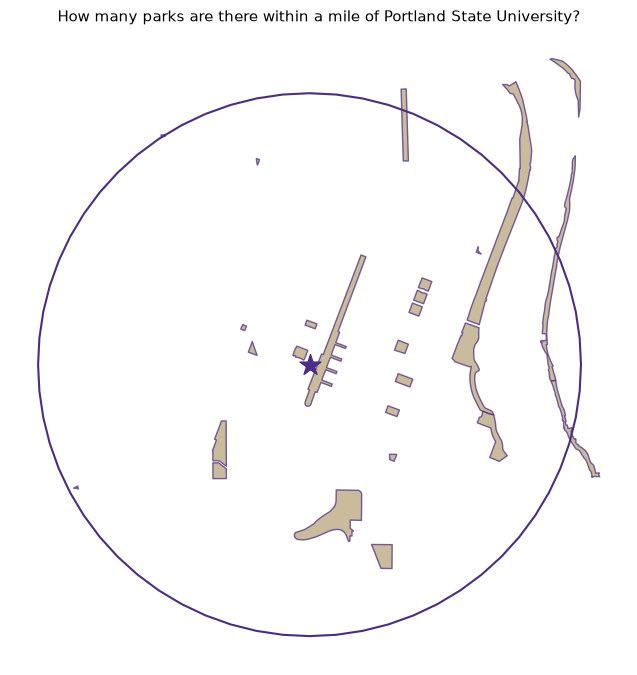

In [9]:
# [Python]
parks = ask("How many parks are there within a mile of Portland State University?")


📍 Within 0.25 miles (402 m) of Powell's Books:
   15 OSM coffee shop elements · 15 unique named coffee shops
     • Caffè Umbria
     • Courier Coffee Roasters
     • Guilder Cafe
     • Java Man
     • Kilo D’Cofi
     • Mako Matcha Mill
     • Never Coffee
     • Nuvrei
     • Oak Street Coffee
     • Roseline Coffee Bar
     • Starbucks
     • Stumptown Coffee Roasters
     • Sweet Coco G
     • The Mezz
     • Water Avenue Coffee Company


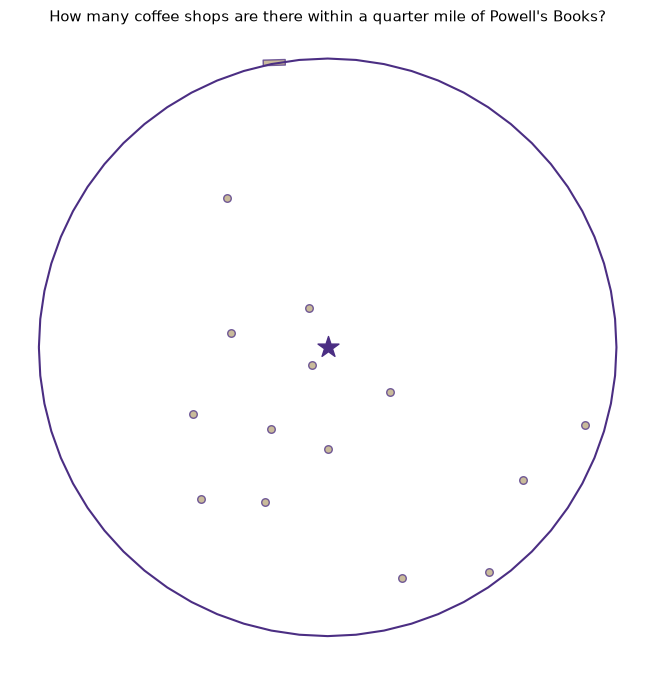

In [10]:
# [Python]
coffee = ask("How many coffee shops are there within a quarter mile of Powell's Books?",
             list_names=True)


In [11]:
# [Python] — graceful failure: unknown vocabulary teaches the user the contract
ask("How many dragons are there within a mile of Portland State University?")


🤔 I don't know 'dragons' yet. I know: bar, bike shop, bookstore, brewery, bus stop, cafe, coffee shop, food cart, grocery store, hospital, library, park, pharmacy, playground, restaurant, school, supermarket.
Add it to TAG_MAP to teach me.


### 🔧 Try it yourself
- *How many breweries are there within 2 miles of the Moda Center?*
- *How many food carts are there within a quarter mile of Pioneer Courthouse Square?*
- *How many bus stops are within 800 meters of Union Station, Portland?*
- Teach the agent a new term: add `"dog park": {"leisure": "dog_park"}` to `TAG_MAP`, rerun
  the vocabulary cell, and ask about dog parks near Laurelhurst Park.
- Change `city_hint` in `geocode()` to another city and ask about *your* neighborhood —
  nothing else in the notebook is Portland-specific.


## 9 — Caveats and where an LLM slots in

**Data honesty.** OSM completeness varies block by block; a count is a count of *mapped* features.
`amenity=cafe` is OSM's notion of a coffee shop — a Starbucks tagged `amenity=fast_food` won't appear.
The element-count vs unique-name gap on parks is a good classroom moment about data models,
not an error.

**Service etiquette.** Nominatim and Overpass are donated infrastructure: cache your geocodes
(Section 5 does), keep request volumes classroom-scale, and set a descriptive `http_user_agent`
(Section 1 does). For heavy use, run your own Overpass instance or use a regional extract.

**Swapping the parser for an LLM.** Stages 2 and 3 don't change at all. Replace `parse_question()`
with a call that asks a model to emit the same structured triple, e.g. with the Anthropic API:

```python
# pip install anthropic   (this path DOES require an API key)
# prompt = f'''Extract JSON {{"what": ..., "distance_m": ..., "place": ...}}
#              from: "{question}". Valid "what" values: {list(TAG_MAP)}'''
# → json.loads(response) → same (tags, radius_m, place) triple → same engine
```

That's the whole upgrade — and the moment this becomes a geoAI agent in earnest. The
rule-based and LLM versions share their ground-and-act stages; only the parser changes. Other easy extensions:
**nearest-X** ("what's the closest pharmacy to...") by sorting `dist_m`; **isochrones**
instead of circles using `ox.graph_from_point()` + network distance; an **arcpy comparison**
cell pairing this against `arcpy.analysis.Buffer` + `SelectLayerByLocation` on the same question.
